In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.lines import Line2D
import pandas as pd


In [63]:
CLASSIF_METHODS = ["ClassifWrapSA(LogisticRegression)",
                   "ClassifWrapSA(SVC)",
                   "ClassifWrapSA(KNeighborsClassifier)",
                   "ClassifWrapSA(DecisionTreeClassifier)",
                   "ClassifWrapSA(RandomForestClassifier)",
                   "ClassifWrapSA(GradientBoostingClassifier)"]

REGR_METHODS = ["RegrWrapSA(ElasticNet)",
                "RegrWrapSA(DecisionTreeRegressor)",
                "RegrWrapSA(RandomForestRegressor)",
                "RegrWrapSA(GradientBoostingRegressor)",
                "RegrWrapSA(SVR)",
                "RegrWrapSA(KNeighborsRegressor)"]

SURV_METHODS = ["SAWrapSA(KaplanMeierFitter)",
                "CoxPHSurvivalAnalysis",
                "RandomSurvivalForest",
                "SurvivalTree",
                "GradientBoostingSurvivalAnalysis",
                "CRAID",
                "ParallelBootstrapCRAID"]

In [64]:
df = pd.read_excel('UI/tables/pbc.xlsx')

In [65]:
df_metrics = df[["METHOD", 'CI_mean', 'IBS_mean', 'AUPRC_mean', 
                 'RMSE_TIME_mean', 'R2_TIME_mean', 
                 'AUC_EVENT_mean', 'LOGLOSS_EVENT_mean', 'RMSE_EVENT_mean'
                ]]

In [66]:
bad_example = ["BAD", 0.5, 0.25, 0.5, 100000.0, -10.0, 0.5, 1.0, 100000.0]
good_example = ["GOOD", 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0]

df_metrics = pd.concat([df_metrics, pd.DataFrame([bad_example, good_example],
                                                 columns=df_metrics.columns)], ignore_index=True)
df_metrics.iloc[:, 1:] = df_metrics.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

In [67]:
df_metrics = df_metrics[["METHOD", 'CI_mean', 'IBS_mean', 'AUPRC_mean', 
                 'RMSE_TIME_mean', 'R2_TIME_mean', 
                #  'AUC_EVENT_mean', 'LOGLOSS_EVENT_mean', 'RMSE_EVENT_mean'
                ]]

### TSNE Visualization

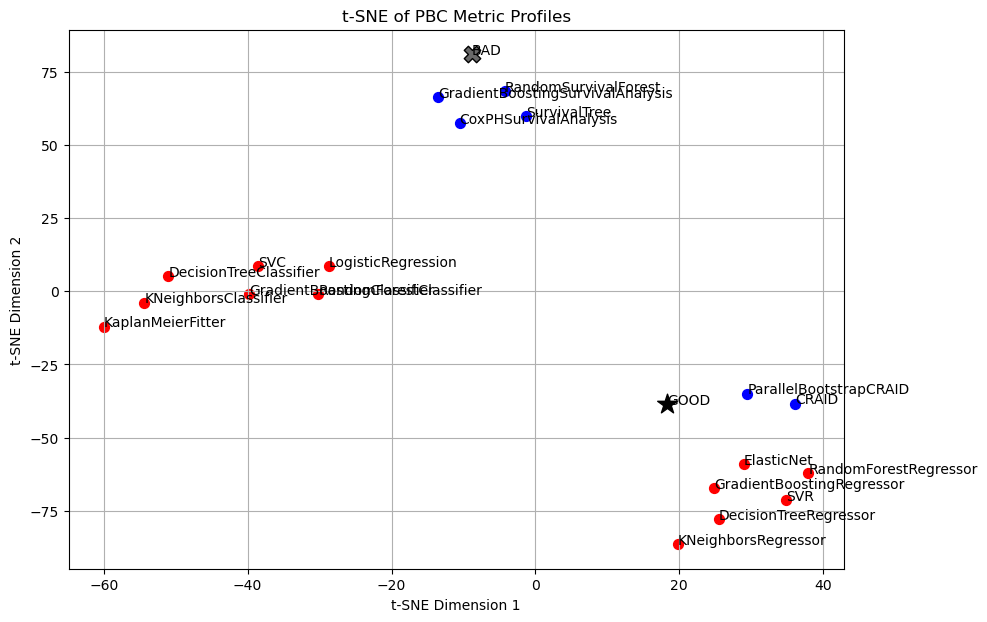

In [68]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# t-SNE here shows similarity of metric profiles on PBC, not the global leaderboard rank.
tsne_df = df_metrics.copy()
real_mask = ~tsne_df['METHOD'].isin(['GOOD', 'BAD'])
tsne_features = tsne_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    tsne_features[col] = -tsne_features[col]

scaler = StandardScaler().fit(tsne_features.loc[real_mask])
scaled_metrics = scaler.transform(tsne_features)
perplexity = max(2, min(5, len(tsne_df) - 1))
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(scaled_metrics)
plt.figure(figsize=(10, 7))
# plt.scatter(tsne_results[:, 0], tsne_results[:, 1])
for i, method in enumerate(tsne_df['METHOD']):
    marker = 'o'
    size = 50
    edgecolor = None
    if method == 'GOOD':
        color = 'black'
        marker = '*'
        size = 220
        edgecolor = 'black'
    elif method == 'BAD':
        color = 'dimgray'
        marker = 'X'
        size = 140
        edgecolor = 'black'
    elif method in SURV_METHODS:
        color = 'blue'
    elif method in CLASSIF_METHODS:
        color = 'green'
    elif method in REGR_METHODS:
        color = 'orange'
    else:
        color = 'red'
    plt.scatter(tsne_results[i, 0], tsne_results[i, 1], color=color, marker=marker, s=size, edgecolors=edgecolor)
    plt.annotate(method, (tsne_results[i, 0], tsne_results[i, 1]))
plt.title('t-SNE of PBC Metric Profiles')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid()
plt.show()

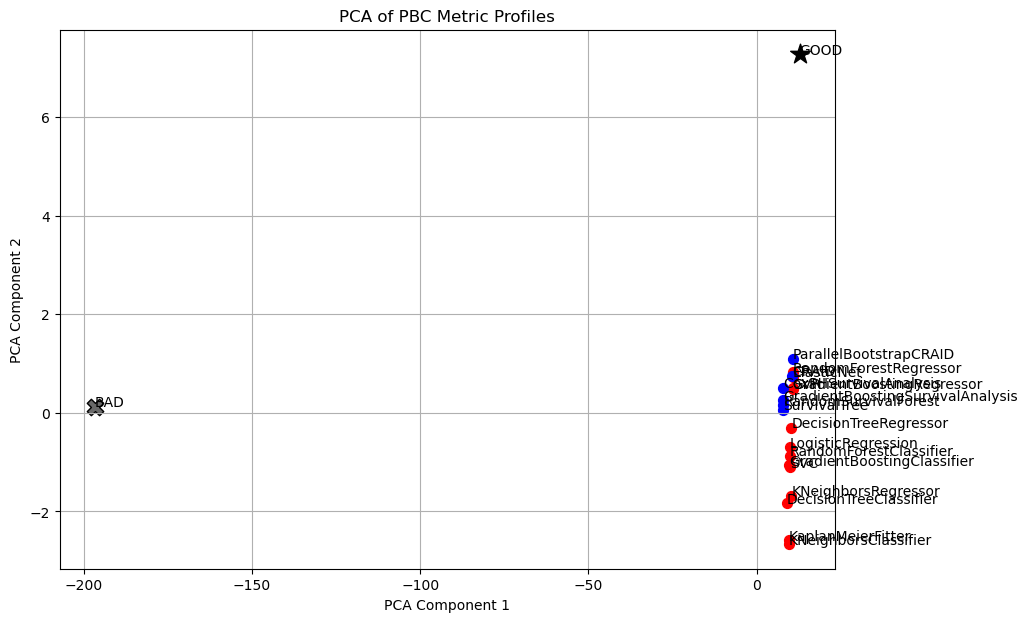

In [69]:
### PCA Visualization

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_df = df_metrics.copy()
real_mask = ~pca_df['METHOD'].isin(['GOOD', 'BAD'])
pca_features = pca_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    pca_features[col] = -pca_features[col]

scaler = StandardScaler().fit(pca_features.loc[real_mask])
scaled_metrics = scaler.transform(pca_features)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_metrics)
plt.figure(figsize=(10, 7))

for i, method in enumerate(pca_df['METHOD']):
    marker = 'o'
    size = 50
    edgecolor = None
    if method == 'GOOD':
        color = 'black'
        marker = '*'
        size = 220
        edgecolor = 'black'
    elif method == 'BAD':
        color = 'dimgray'
        marker = 'X'
        size = 140
        edgecolor = 'black'
    elif method in SURV_METHODS:
        color = 'blue'
    elif method in CLASSIF_METHODS:
        color = 'green'
    elif method in REGR_METHODS:
        color = 'orange'
    else:
        color = 'red'
    plt.scatter(pca_results[i, 0], pca_results[i, 1], color=color, marker=marker, s=size, edgecolors=edgecolor)
    plt.annotate(method, (pca_results[i, 0], pca_results[i, 1]))

plt.title('PCA of PBC Metric Profiles')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid()
plt.show()

d:\Users\DimonZhi\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


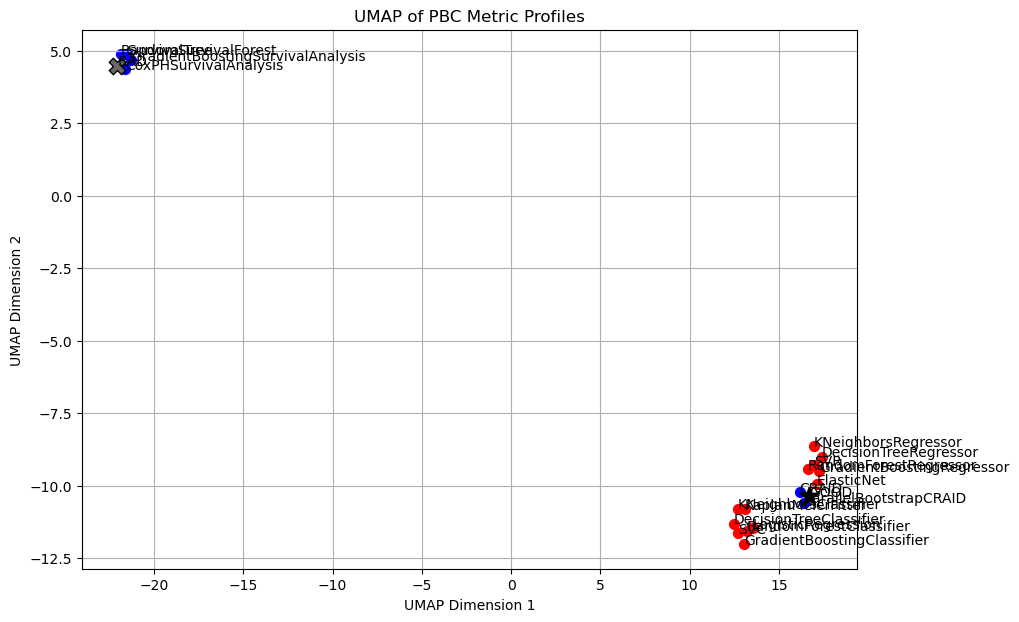

In [70]:
### UMAP Visualization

from umap import UMAP
from sklearn.preprocessing import StandardScaler

umap_df = df_metrics.copy()
real_mask = ~umap_df['METHOD'].isin(['GOOD', 'BAD'])
umap_features = umap_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    umap_features[col] = -umap_features[col]

scaler = StandardScaler().fit(umap_features.loc[real_mask])
scaled_metrics = scaler.transform(umap_features)
n_neighbors = max(2, min(8, len(umap_df) - 1))

umap = UMAP(n_components=2, n_neighbors=n_neighbors, random_state=42, min_dist=0.1)
umap_results = umap.fit_transform(scaled_metrics)
plt.figure(figsize=(10, 7))

for i, method in enumerate(umap_df['METHOD']):
    marker = 'o'
    size = 50
    edgecolor = None
    if method == 'GOOD':
        color = 'black'
        marker = '*'
        size = 220
        edgecolor = 'black'
    elif method == 'BAD':
        color = 'dimgray'
        marker = 'X'
        size = 140
        edgecolor = 'black'
    elif method in SURV_METHODS:
        color = 'blue'
    elif method in CLASSIF_METHODS:
        color = 'green'
    elif method in REGR_METHODS:
        color = 'orange'
    else:
        color = 'red'
    plt.scatter(umap_results[i, 0], umap_results[i, 1], color=color, marker=marker, s=size, edgecolors=edgecolor)
    plt.annotate(method, (umap_results[i, 0], umap_results[i, 1]))

plt.title('UMAP of PBC Metric Profiles')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid()
plt.show()

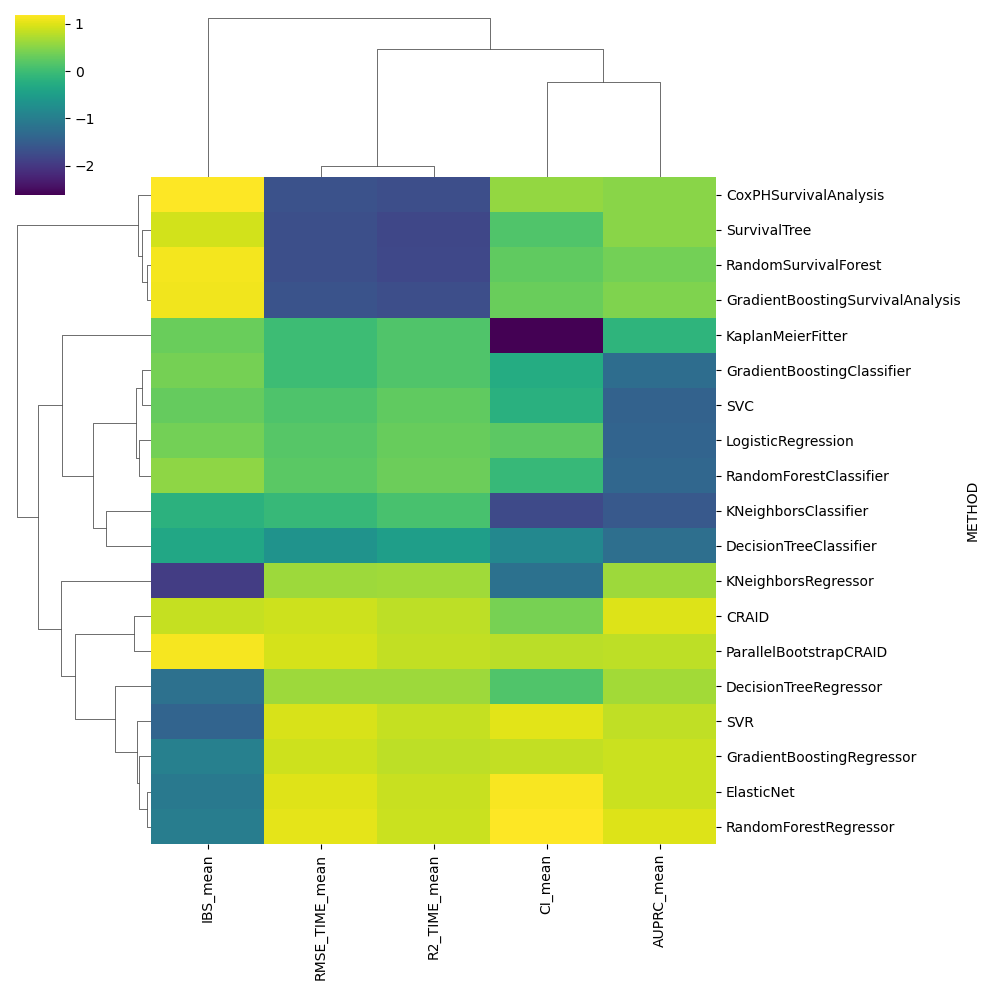

In [71]:
import seaborn as sns

cluster_df = df_metrics[~df_metrics['METHOD'].isin(['GOOD', 'BAD'])].copy()
cluster_features = cluster_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    cluster_features[col] = -cluster_features[col]
cluster_features.index = cluster_df['METHOD']

sns.clustermap(cluster_features.astype(float),
               cmap='viridis',
               z_score=1,
               col_cluster=True,
               row_cluster=True)

,Method,CLASSIFICATION_Avg_Position,SURVIVAL_Avg_Position,group,family_name,family_label,base_model,base_model_short,times,plot_label,delta,abs_delta
0,RandomForestClassifier,2.000000,13.571429,classification,,Classification,RandomForestClassifier,RF,None,RandomForestClassifier,-11.571429,11.571429
1,GradientBoostingClassifier,2.142857,13.428571,classification,,Classification,GradientBoostingClassifier,GB,None,GradientBoostingClassifier,-11.285714,11.285714
2,LogisticRegression,4.714286,13.571429,classification,,Classification,LogisticRegression,LR,None,LogisticRegression,-8.857143,8.857143
3,GradientBoostingSurvivalAnalysis,4.857143,3.285714,survival,,Survival,GradientBoostingSurvivalAnalysis,GBSA,None,GradientBoostingSurvivalAnalysis,1.571429,1.571429
4,SVC,5.571429,14.714286,classification,,Classification,SVC,SVC,None,SVC,-9.142857,9.142857
5,RandomSurvivalForest,6.428571,5.714286,survival,,Survival,RandomSurvivalForest,RSF,None,RandomSurvivalForest,0.714286,0.714286
6,ParallelBootstrapCRAID,7.285714,1.285714,survival,,Survival,ParallelBootstrapCRAID,PB-CRAID,None,ParallelBootstrapCRAID,6.000000,6.000000
7,CoxPHSurvivalAnalysis,8.428571,6.428571,survival,,Survival,CoxPHSurvivalAnalysis,CoxPH,None,CoxPHSurvivalAnalysis,2.000000,2.000000
8,CRAID,9.714286,3.000000,survival,,Survival,CRAID,CRAID,None,CRAID,6.714286,6.714286
9,ElasticNet,12.000000,8.142857,regression,,Regression,ElasticNet,ElasticNet,None,ElasticNet,3.857143,3.857143


,Method,plot_label,family_label,base_model,times,CLASSIFICATION_Avg_Position,SURVIVAL_Avg_Position,delta,abs_delta
0,RandomForestClassifier,RandomForestClassifier,Classification,RandomForestClassifier,None,2.000000,13.571429,-11.571429,11.571429
1,GradientBoostingClassifier,GradientBoostingClassifier,Classification,GradientBoostingClassifier,None,2.142857,13.428571,-11.285714,11.285714
2,LogisticRegression,LogisticRegression,Classification,LogisticRegression,None,4.714286,13.571429,-8.857143,8.857143
3,GradientBoostingSurvivalAnalysis,GradientBoostingSurvivalAnalysis,Survival,GradientBoostingSurvivalAnalysis,None,4.857143,3.285714,1.571429,1.571429
4,SVC,SVC,Classification,SVC,None,5.571429,14.714286,-9.142857,9.142857
5,RandomSurvivalForest,RandomSurvivalForest,Survival,RandomSurvivalForest,None,6.428571,5.714286,0.714286,0.714286
6,ParallelBootstrapCRAID,ParallelBootstrapCRAID,Survival,ParallelBootstrapCRAID,None,7.285714,1.285714,6.000000,6.000000
7,CoxPHSurvivalAnalysis,CoxPHSurvivalAnalysis,Survival,CoxPHSurvivalAnalysis,None,8.428571,6.428571,2.000000,2.000000
8,CRAID,CRAID,Survival,CRAID,None,9.714286,3.000000,6.714286,6.714286
9,ElasticNet,ElasticNet,Regression,ElasticNet,None,12.000000,8.142857,3.857143,3.857143


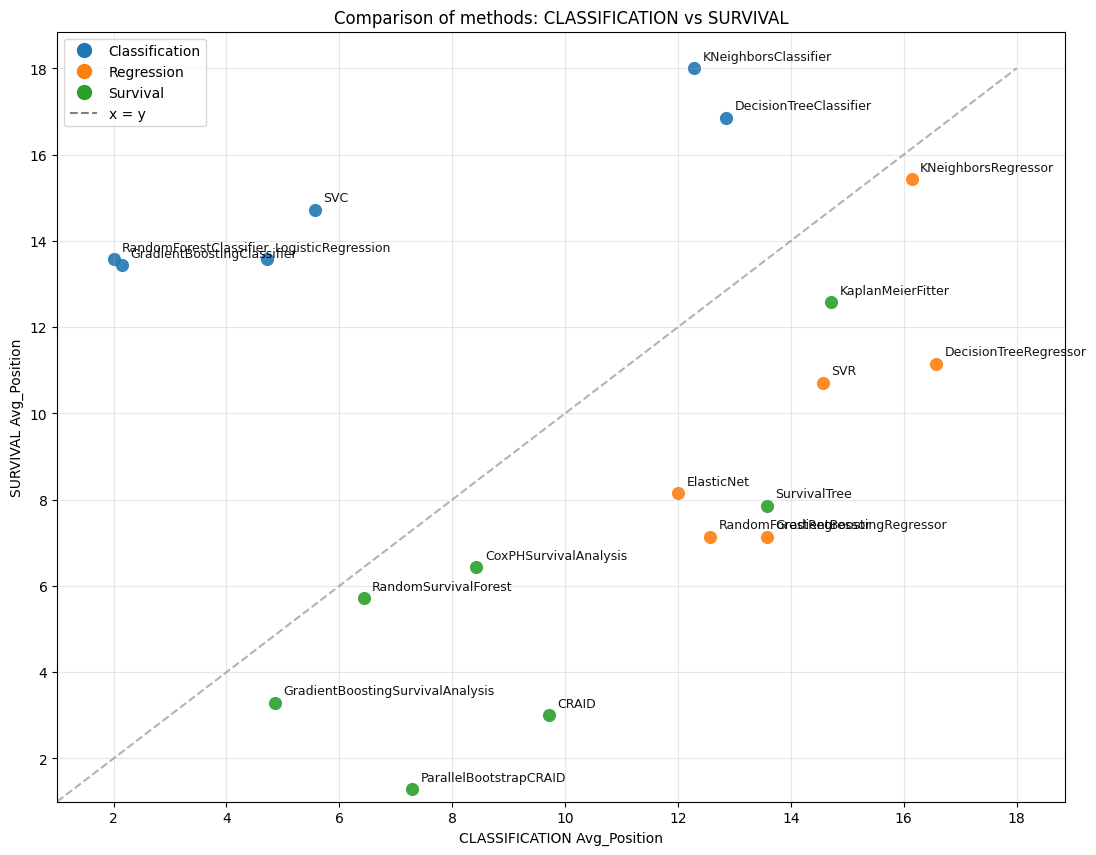

In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

LEADERBOARD_PATH = "UI/tables/leaderboards_by_task.xlsx"
USE_COL = "Avg_Position"

SHEET_MAP = {
    "CLASSIFICATION": "OVERALL_CLASSIFICATION",
    "REGRESSION": "OVERALL_REGRESSION",
    "SURVIVAL": "OVERALL_SURVIVAL",
    "ALL": "OVERALL_ALL",
}

CLASSIF_MODELS = [
    "LogisticRegression",
    "KNeighborsClassifier",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
    "SVC",
]

REGR_MODELS = [
    "ElasticNet",
    "DecisionTreeRegressor",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "SVR",
    "KNeighborsRegressor",
]

SURV_MODELS = [
    "KaplanMeierFitter",
    "CoxPHSurvivalAnalysis",
    "RandomSurvivalForest",
    "SurvivalTree",
    "GradientBoostingSurvivalAnalysis",
    "CRAID",
    "ParallelBootstrapCRAID",
]

SHORT_MODEL_NAMES = {
    "LogisticRegression": "LR",
    "KNeighborsClassifier": "KNN",
    "DecisionTreeClassifier": "DT",
    "RandomForestClassifier": "RF",
    "GradientBoostingClassifier": "GB",
    "DecisionTreeRegressor": "DT-R",
    "RandomForestRegressor": "RF-R",
    "GradientBoostingRegressor": "GB-R",
    "KNeighborsRegressor": "KNN-R",
    "KaplanMeierFitter": "KMF",
    "CoxPHSurvivalAnalysis": "CoxPH",
    "RandomSurvivalForest": "RSF",
    "SurvivalTree": "ST",
    "GradientBoostingSurvivalAnalysis": "GBSA",
    "ParallelBootstrapCRAID": "PB-CRAID",
}

PIECEWISE_PATTERN = re.compile(
    r"^(Piecewise(?:CensorAware)?ClassifWrapSA)\(([^,]+),\s*times=(\d+)\)$"
)

PIECEWISE_GROUPS = {
    "PiecewiseClassifWrapSA": "piecewise",
    "PiecewiseCensorAwareClassifWrapSA": "piecewise_censor_aware",
}

METHOD_STYLES = {
    "classification": {"label": "Classification", "color": "tab:blue"},
    "regression": {"label": "Regression", "color": "tab:orange"},
    "survival": {"label": "Survival", "color": "tab:green"},
    "piecewise": {"label": "PiecewiseClassifWrapSA", "color": "#ef4444"},
    "piecewise_censor_aware": {"label": "PiecewiseCensorAwareClassifWrapSA", "color": "#facc15"},
    "other": {"label": "Other", "color": "tab:gray"},
}

TIME_MARKERS = {
    4: "D",
    8: "P",
    16: "X",
    32: "*",
}

TIME_SIZES = {
    4: 125,
    8: 145,
    16: 165,
    32: 220,
}

TIME_LABELS = {
    4: "times=4",
    8: "times=8",
    16: "times=16",
    32: "times=32",
}

SELECTED_PIECEWISE_TIMES = {16}

def parse_piecewise_method(method):
    match = PIECEWISE_PATTERN.match(str(method))
    if not match:
        return None

    family_name, base_model, times = match.groups()
    group = PIECEWISE_GROUPS[family_name]
    times = int(times)
    short_model = SHORT_MODEL_NAMES.get(base_model, base_model)

    return {
        "group": group,
        "family_name": family_name,
        "family_label": METHOD_STYLES[group]["label"],
        "base_model": base_model,
        "base_model_short": base_model,
        "times": times,
        "plot_label": f"{base_model} t={times}",
    }



def method_metadata(method):
    piecewise = parse_piecewise_method(method)
    if piecewise is not None:
        return piecewise

    if method in CLASSIF_MODELS:
        group = "classification"
    elif method in REGR_MODELS:
        group = "regression"
    elif method in SURV_MODELS:
        group = "survival"
    else:
        group = "other"

    return {
        "group": group,
        "family_name": "",
        "family_label": METHOD_STYLES[group]["label"],
        "base_model": method,
        "base_model_short": SHORT_MODEL_NAMES.get(method, method),
        "times": None,
        "plot_label": method,
    }



def style_for_method(method):
    meta = method_metadata(method)
    style = METHOD_STYLES[meta["group"]].copy()

    if meta["times"] is None:
        style.update({
            "marker": "o",
            "size": 90,
            "edgecolor": style["color"],
            "linewidth": 0,
        })
    else:
        style.update({
            "marker": TIME_MARKERS.get(meta["times"], "^"),
            "size": TIME_SIZES.get(meta["times"], 150),
            "edgecolor": "black",
            "linewidth": 0.85,
        })

    return style



def build_legend_elements(cmp):
    legend = []
    present_groups = list(dict.fromkeys(cmp["group"].tolist()))

    for group_name in ["classification", "regression", "survival", "piecewise", "piecewise_censor_aware", "other"]:
        if group_name not in present_groups:
            continue
        style = METHOD_STYLES[group_name]
        legend.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=style["label"],
                markerfacecolor=style["color"],
                markeredgecolor=style["color"],
                markersize=10,
            )
        )

    present_times = sorted({int(value) for value in cmp["times"].dropna().tolist()})
    for times in present_times:
        legend.append(
            Line2D(
                [0],
                [0],
                marker=TIME_MARKERS.get(times, "^"),
                color="black",
                label=TIME_LABELS.get(times, f"times={times}"),
                markerfacecolor="white",
                markeredgecolor="black",
                linestyle="None",
                markersize=10,
            )
        )

    legend.append(Line2D([0], [0], linestyle="--", color="gray", label="x = y"))
    return legend



def render_task_comparison(task_x, task_y, use_col=USE_COL):
    x_col = f"{task_x}_{use_col}"
    y_col = f"{task_y}_{use_col}"

    df_x = pd.read_excel(LEADERBOARD_PATH, sheet_name=SHEET_MAP[task_x])
    df_y = pd.read_excel(LEADERBOARD_PATH, sheet_name=SHEET_MAP[task_y])

    df_x = df_x[["Method", use_col]].rename(columns={use_col: x_col})
    df_y = df_y[["Method", use_col]].rename(columns={use_col: y_col})

    cmp = df_x.merge(df_y, on="Method", how="inner")
    meta = cmp["Method"].apply(method_metadata).apply(pd.Series)
    cmp = pd.concat([cmp, meta], axis=1)
    cmp = cmp[cmp["times"].isna() | cmp["times"].isin(SELECTED_PIECEWISE_TIMES)].copy()
    cmp["delta"] = cmp[x_col] - cmp[y_col]
    cmp["abs_delta"] = cmp["delta"].abs()
    cmp = cmp.sort_values([x_col, y_col, "group", "times", "Method"], na_position="last").reset_index(drop=True)

    display(cmp)

    rank_table = cmp[[
        "Method",
        "plot_label",
        "family_label",
        "base_model",
        "times",
        x_col,
        y_col,
        "delta",
        "abs_delta",
    ]].copy()
    display(rank_table)

    plt.figure(figsize=(13, 10))

    for _, row in cmp.iterrows():
        style = style_for_method(row["Method"])
        plt.scatter(
            row[x_col],
            row[y_col],
            color=style["color"],
            marker=style["marker"],
            s=style["size"],
            alpha=0.9,
            edgecolors=style["edgecolor"],
            linewidths=style["linewidth"],
        )
        plt.annotate(
            row["plot_label"],
            (row[x_col], row[y_col]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9,
            alpha=0.92,
        )

    xy_min = 1
    xy_max = max(cmp[x_col].max(), cmp[y_col].max())
    plt.plot([xy_min, xy_max], [xy_min, xy_max], "--", color="gray", alpha=0.6)
    plt.xlim(left=xy_min)
    plt.ylim(bottom=xy_min)
    plt.legend(handles=build_legend_elements(cmp), loc="best")

    plt.xlabel(f"{task_x} {use_col}")
    plt.ylabel(f"{task_y} {use_col}")
    plt.title(f"Comparison of methods: {task_x} vs {task_y}")
    plt.grid(alpha=0.3)
    plt.show()

    return cmp, rank_table


cmp_cs, rank_cs = render_task_comparison("CLASSIFICATION", "SURVIVAL")


,Method,SURVIVAL_Avg_Position,REGRESSION_Avg_Position,group,family_name,family_label,base_model,base_model_short,times,plot_label,delta,abs_delta
0,ParallelBootstrapCRAID,1.285714,4.000000,survival,,Survival,ParallelBootstrapCRAID,PB-CRAID,None,ParallelBootstrapCRAID,-2.714286,2.714286
1,CRAID,3.000000,6.142857,survival,,Survival,CRAID,CRAID,None,CRAID,-3.142857,3.142857
2,GradientBoostingSurvivalAnalysis,3.285714,12.428571,survival,,Survival,GradientBoostingSurvivalAnalysis,GBSA,None,GradientBoostingSurvivalAnalysis,-9.142857,9.142857
3,RandomSurvivalForest,5.714286,16.714286,survival,,Survival,RandomSurvivalForest,RSF,None,RandomSurvivalForest,-11.000000,11.000000
4,CoxPHSurvivalAnalysis,6.428571,13.000000,survival,,Survival,CoxPHSurvivalAnalysis,CoxPH,None,CoxPHSurvivalAnalysis,-6.571429,6.571429
5,RandomForestRegressor,7.142857,1.714286,regression,,Regression,RandomForestRegressor,RF-R,None,RandomForestRegressor,5.428571,5.428571
6,GradientBoostingRegressor,7.142857,2.714286,regression,,Regression,GradientBoostingRegressor,GB-R,None,GradientBoostingRegressor,4.428571,4.428571
7,SurvivalTree,7.857143,17.857143,survival,,Survival,SurvivalTree,ST,None,SurvivalTree,-10.000000,10.000000
8,ElasticNet,8.142857,3.714286,regression,,Regression,ElasticNet,ElasticNet,None,ElasticNet,4.428571,4.428571
9,SVR,10.714286,6.000000,regression,,Regression,SVR,SVR,None,SVR,4.714286,4.714286


,Method,plot_label,family_label,base_model,times,SURVIVAL_Avg_Position,REGRESSION_Avg_Position,delta,abs_delta
0,ParallelBootstrapCRAID,ParallelBootstrapCRAID,Survival,ParallelBootstrapCRAID,None,1.285714,4.000000,-2.714286,2.714286
1,CRAID,CRAID,Survival,CRAID,None,3.000000,6.142857,-3.142857,3.142857
2,GradientBoostingSurvivalAnalysis,GradientBoostingSurvivalAnalysis,Survival,GradientBoostingSurvivalAnalysis,None,3.285714,12.428571,-9.142857,9.142857
3,RandomSurvivalForest,RandomSurvivalForest,Survival,RandomSurvivalForest,None,5.714286,16.714286,-11.000000,11.000000
4,CoxPHSurvivalAnalysis,CoxPHSurvivalAnalysis,Survival,CoxPHSurvivalAnalysis,None,6.428571,13.000000,-6.571429,6.571429
5,RandomForestRegressor,RandomForestRegressor,Regression,RandomForestRegressor,None,7.142857,1.714286,5.428571,5.428571
6,GradientBoostingRegressor,GradientBoostingRegressor,Regression,GradientBoostingRegressor,None,7.142857,2.714286,4.428571,4.428571
7,SurvivalTree,SurvivalTree,Survival,SurvivalTree,None,7.857143,17.857143,-10.000000,10.000000
8,ElasticNet,ElasticNet,Regression,ElasticNet,None,8.142857,3.714286,4.428571,4.428571
9,SVR,SVR,Regression,SVR,None,10.714286,6.000000,4.714286,4.714286


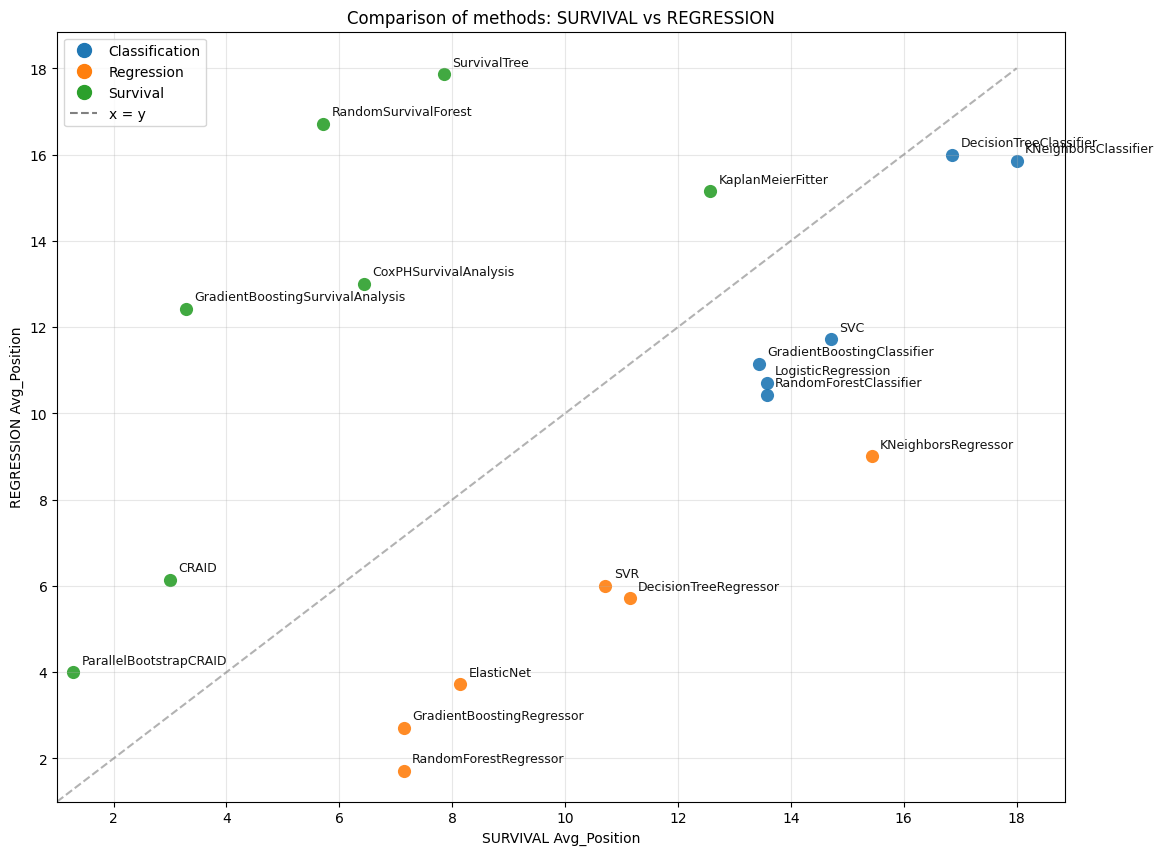

In [10]:
cmp_sr, rank_sr = render_task_comparison("SURVIVAL", "REGRESSION")


,Method,REGRESSION_Avg_Position,CLASSIFICATION_Avg_Position,group,family_name,family_label,base_model,base_model_short,times,plot_label,delta,abs_delta
0,RandomForestRegressor,1.714286,12.571429,regression,,Regression,RandomForestRegressor,RF-R,None,RandomForestRegressor,-10.857143,10.857143
1,GradientBoostingRegressor,2.714286,13.571429,regression,,Regression,GradientBoostingRegressor,GB-R,None,GradientBoostingRegressor,-10.857143,10.857143
2,ElasticNet,3.714286,12.000000,regression,,Regression,ElasticNet,ElasticNet,None,ElasticNet,-8.285714,8.285714
3,ParallelBootstrapCRAID,4.000000,7.285714,survival,,Survival,ParallelBootstrapCRAID,PB-CRAID,None,ParallelBootstrapCRAID,-3.285714,3.285714
4,DecisionTreeRegressor,5.714286,16.571429,regression,,Regression,DecisionTreeRegressor,DT-R,None,DecisionTreeRegressor,-10.857143,10.857143
5,SVR,6.000000,14.571429,regression,,Regression,SVR,SVR,None,SVR,-8.571429,8.571429
6,CRAID,6.142857,9.714286,survival,,Survival,CRAID,CRAID,None,CRAID,-3.571429,3.571429
7,KNeighborsRegressor,9.000000,16.142857,regression,,Regression,KNeighborsRegressor,KNN-R,None,KNeighborsRegressor,-7.142857,7.142857
8,RandomForestClassifier,10.428571,2.000000,classification,,Classification,RandomForestClassifier,RF,None,RandomForestClassifier,8.428571,8.428571
9,LogisticRegression,10.714286,4.714286,classification,,Classification,LogisticRegression,LR,None,LogisticRegression,6.000000,6.000000


,Method,plot_label,family_label,base_model,times,REGRESSION_Avg_Position,CLASSIFICATION_Avg_Position,delta,abs_delta
0,RandomForestRegressor,RandomForestRegressor,Regression,RandomForestRegressor,None,1.714286,12.571429,-10.857143,10.857143
1,GradientBoostingRegressor,GradientBoostingRegressor,Regression,GradientBoostingRegressor,None,2.714286,13.571429,-10.857143,10.857143
2,ElasticNet,ElasticNet,Regression,ElasticNet,None,3.714286,12.000000,-8.285714,8.285714
3,ParallelBootstrapCRAID,ParallelBootstrapCRAID,Survival,ParallelBootstrapCRAID,None,4.000000,7.285714,-3.285714,3.285714
4,DecisionTreeRegressor,DecisionTreeRegressor,Regression,DecisionTreeRegressor,None,5.714286,16.571429,-10.857143,10.857143
5,SVR,SVR,Regression,SVR,None,6.000000,14.571429,-8.571429,8.571429
6,CRAID,CRAID,Survival,CRAID,None,6.142857,9.714286,-3.571429,3.571429
7,KNeighborsRegressor,KNeighborsRegressor,Regression,KNeighborsRegressor,None,9.000000,16.142857,-7.142857,7.142857
8,RandomForestClassifier,RandomForestClassifier,Classification,RandomForestClassifier,None,10.428571,2.000000,8.428571,8.428571
9,LogisticRegression,LogisticRegression,Classification,LogisticRegression,None,10.714286,4.714286,6.000000,6.000000


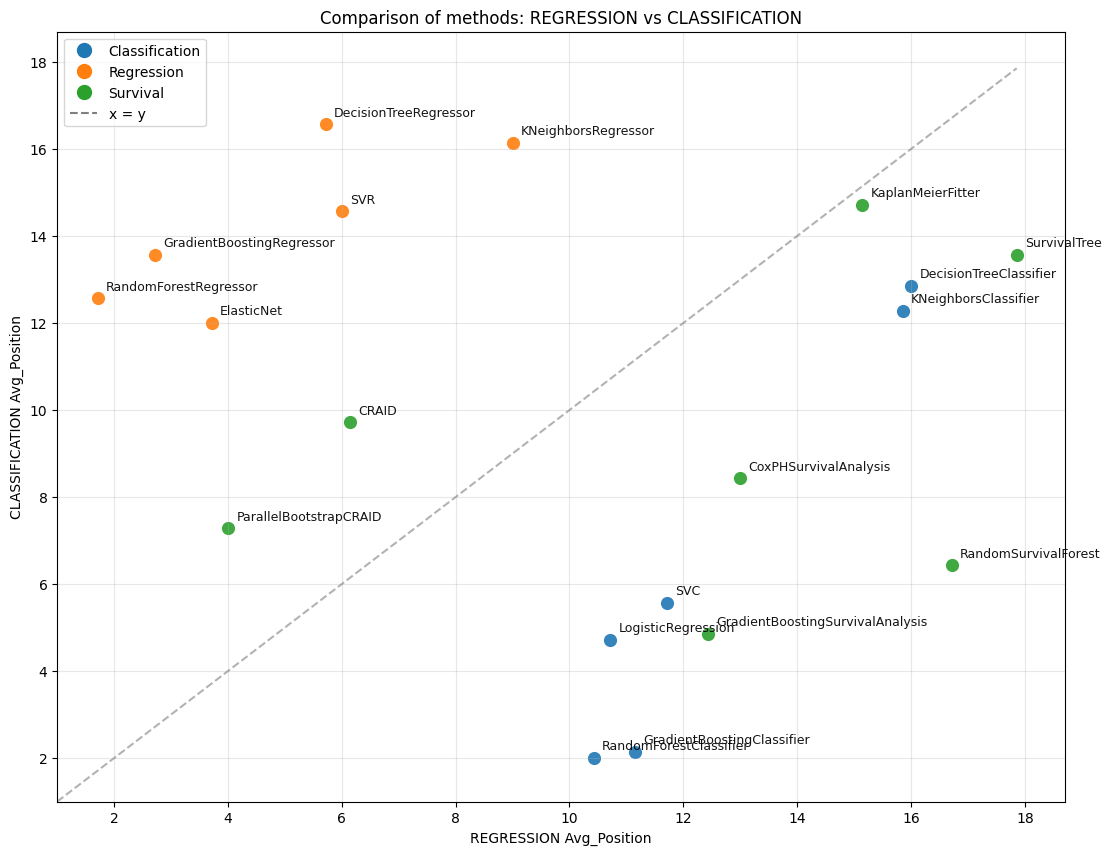

In [11]:
cmp_rc, rank_rc = render_task_comparison("REGRESSION", "CLASSIFICATION")


In [ ]:
import json
import uuid
import pandas as pd
from IPython.display import HTML, display

TYPE_COLORS = {
    "classification": "#dbeafe",
    "regression": "#ffedd5",
    "survival": "#dcfce7",
    "piecewise": "#fee2e2",
    "piecewise_censor_aware": "#fef3c7",
    "other": "#e5e7eb",
}

TIME_BG_COLORS = {
    4: "#fef3c7",
    8: "#fde68a",
    16: "#fdba74",
    32: "#fb7185",
}

leaderboard = pd.read_excel(LEADERBOARD_PATH, sheet_name="OVERALL_ALL")
leaderboard = leaderboard[["Overall_position", "Method", "Avg_Position"]].copy()
leaderboard_meta = leaderboard["Method"].apply(method_metadata).apply(pd.Series)
leaderboard = pd.concat([leaderboard, leaderboard_meta], axis=1)
leaderboard = leaderboard[leaderboard["times"].isna() | leaderboard["times"].isin(SELECTED_PIECEWISE_TIMES)].copy()
leaderboard = leaderboard[[
    "Overall_position",
    "Method",
    "plot_label",
    "family_label",
    "base_model_short",
    "times",
    "Avg_Position",
]].copy()
leaderboard.columns = ["Место", "Название модели", "Метка", "Тип", "База", "Times", "Avg_Position"]
leaderboard["Место"] = leaderboard["Место"].astype(int)
leaderboard["Avg_Position"] = pd.to_numeric(leaderboard["Avg_Position"], errors="coerce").round(3)
leaderboard["Times"] = leaderboard["Times"].astype("Int64")


def leaderboard_row_style(row):
    meta = method_metadata(row["Название модели"])
    group_bg = TYPE_COLORS.get(meta["group"], "")
    time_bg = TIME_BG_COLORS.get(meta["times"], "") if meta["times"] is not None else ""
    styles = []

    for column in row.index:
        style_parts = []
        if column in ("Название модели", "Метка", "Тип", "База") and group_bg:
            style_parts.append(f"background-color: {group_bg}")
        if column == "Times" and time_bg:
            style_parts.append(f"background-color: {time_bg}")
            style_parts.append("font-weight: 700")
        styles.append("; ".join(style_parts))

    return styles


styled_leaderboard = (
    leaderboard.style
    .hide(axis="index")
    .format({"Avg_Position": "{:.3f}"}, na_rep="")
    .apply(leaderboard_row_style, axis=1)
    .background_gradient(subset=["Avg_Position"], cmap="Blues_r")
    .set_caption("Leaderboard with Piecewise Variants and Times")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "18px"), ("font-weight", "700"), ("text-align", "left"), ("margin-bottom", "8px")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%"), ("font-size", "14px"), ("border", "1px solid #dbe4f0")]},
        {"selector": "th", "props": [("background-color", "#0f172a"), ("color", "white"), ("padding", "10px 12px"), ("border", "1px solid #dbe4f0"), ("text-align", "left")]},
        {"selector": "td", "props": [("padding", "8px 12px"), ("border", "1px solid #dbe4f0")]},
    ])
    .set_properties(subset=["Место", "Тип", "Times", "Avg_Position"], **{"text-align": "center", "font-weight": "600"})
    .set_properties(subset=["Название модели", "Метка", "База"], **{"text-align": "left"})
)

styled_html = styled_leaderboard.to_html()
plain_text = leaderboard.to_csv(sep="	", index=False)
table_id = f"leaderboard-{uuid.uuid4().hex}"
button_id = f"{table_id}-copy"

display(HTML(f"""
<div style="display:flex; justify-content:flex-end; margin:0 0 10px 0;">
  <button id="{button_id}" style="border:1px solid #cbd5e1; background:#ffffff; color:#0f172a; border-radius:999px; padding:6px 12px; font-size:13px; font-weight:600; cursor:pointer;">Скопировать с оформлением</button>
</div>
<div id="{table_id}">{styled_html}</div>
<script>
(() => {{
  const button = document.getElementById({json.dumps(button_id)});
  const wrapper = document.getElementById({json.dumps(table_id)});
  const html = wrapper ? wrapper.innerHTML : "";
  const text = {json.dumps(plain_text)};

  if (!button || !wrapper) return;

  button.addEventListener("click", async () => {{
    try {{
      if (navigator.clipboard && window.ClipboardItem) {{
        const item = new ClipboardItem({{
          "text/html": new Blob([html], {{ type: "text/html" }}),
          "text/plain": new Blob([text], {{ type: "text/plain" }}),
        }});
        await navigator.clipboard.write([item]);
      }} else {{
        const range = document.createRange();
        range.selectNode(wrapper);
        const selection = window.getSelection();
        selection.removeAllRanges();
        selection.addRange(range);
        document.execCommand("copy");
        selection.removeAllRanges();
      }}

      const oldText = button.textContent;
      button.textContent = "Скопировано";
      setTimeout(() => {{ button.textContent = oldText; }}, 1600);
    }} catch (error) {{
      console.error(error);
      button.textContent = "Не удалось";
      setTimeout(() => {{ button.textContent = "Скопировать с оформлением"; }}, 1600);
    }}
  }});
}})();
</script>
"""))
